<a href="https://colab.research.google.com/github/omark243/Big-Data-/blob/main/Heart_Disease_Big_Data_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

import joblib


# **Load Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# **Dataset Overview**

In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicated Rows:")
print(df.duplicated().sum())

print("\nTarget Distribution:")
print(df["target"].value_counts())

Dataset Shape: (1025, 14)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Missing 

# **Remove Duplicates**

In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print(df["target"].value_counts())

Shape after removing duplicates: (302, 14)
target
1    164
0    138
Name: count, dtype: int64


# **Basic Statistics**

In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# **Big Data Processing Using PySpark**

In this section, we use **PySpark** to cover the Big Data part of the project.

Although the dataset is small enough to be processed using Pandas, PySpark is added to demonstrate scalable Big Data processing concepts.

To avoid repetition, the DataFrame operations required in the project such as **filtering, grouping, and aggregation** are implemented here using **Spark DataFrames**, while Pandas is used later for visualization and machine learning.

So, the role of PySpark in this project is:

- Reading the cleaned dataset as a Spark DataFrame
- Inspecting the schema
- Applying filtering
- Applying grouping and aggregation
- Extracting insights in a scalable way



# **Install PySpark**

In [ ]:
!pip -q install pyspark

# **Create Spark Session**

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, min, max

spark = SparkSession.builder \
    .appName("Heart Disease Big Data Project") \
    .getOrCreate()

spark

# **Save Cleaned Data and Load with Spark**

In [ ]:
cleaned_path = "/content/heart_cleaned.csv"

df.to_csv(cleaned_path, index=False)

spark_df = spark.read.csv(
    cleaned_path,
    header=True,
    inferSchema=True
)

spark_df.show(5)

+---+---+---+--------+----+---+-------+-------+-----+-------+-----+---+----+------+
|age|sex| cp|trestbps|chol|fbs|restecg|thalach|exang|oldpeak|slope| ca|thal|target|
+---+---+---+--------+----+---+-------+-------+-----+-------+-----+---+----+------+
| 52|  1|  0|     125| 212|  0|      1|    168|    0|    1.0|    2|  2|   3|     0|
| 53|  1|  0|     140| 203|  1|      0|    155|    1|    3.1|    0|  0|   3|     0|
| 70|  1|  0|     145| 174|  0|      1|    125|    1|    2.6|    0|  0|   3|     0|
| 61|  1|  0|     148| 203|  0|      1|    161|    0|    0.0|    2|  1|   3|     0|
| 62|  0|  0|     138| 294|  1|      1|    106|    0|    1.9|    1|  3|   2|     0|
+---+---+---+--------+----+---+-------+-------+-----+-------+-----+---+----+------+
only showing top 5 rows


# **Spark Schema**

In [ ]:
spark_df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- sex: integer (nullable = true)
 |-- cp: integer (nullable = true)
 |-- trestbps: integer (nullable = true)
 |-- chol: integer (nullable = true)
 |-- fbs: integer (nullable = true)
 |-- restecg: integer (nullable = true)
 |-- thalach: integer (nullable = true)
 |-- exang: integer (nullable = true)
 |-- oldpeak: double (nullable = true)
 |-- slope: integer (nullable = true)
 |-- ca: integer (nullable = true)
 |-- thal: integer (nullable = true)
 |-- target: integer (nullable = true)



# **Spark Filtering**

In [ ]:
spark_high_risk = spark_df.filter(
    (col("age") > 50) & (col("chol") > 240)
)

print("Patients older than 50 with cholesterol greater than 240:")
spark_high_risk.show(10)

print("Count:", spark_high_risk.count())

Patients older than 50 with cholesterol greater than 240:
+---+---+---+--------+----+---+-------+-------+-----+-------+-----+---+----+------+
|age|sex| cp|trestbps|chol|fbs|restecg|thalach|exang|oldpeak|slope| ca|thal|target|
+---+---+---+--------+----+---+-------+-------+-----+-------+-----+---+----+------+
| 62|  0|  0|     138| 294|  1|      1|    106|    0|    1.9|    1|  3|   2|     0|
| 58|  0|  0|     100| 248|  0|      0|    122|    0|    1.0|    1|  0|   2|     1|
| 58|  1|  0|     114| 318|  0|      2|    140|    0|    4.4|    0|  3|   1|     0|
| 55|  1|  0|     160| 289|  0|      0|    145|    1|    0.8|    1|  1|   3|     0|
| 54|  1|  0|     122| 286|  0|      0|    116|    1|    3.2|    1|  2|   2|     0|
| 51|  1|  0|     140| 298|  0|      1|    122|    1|    4.2|    1|  3|   3|     0|
| 51|  0|  2|     140| 308|  0|      0|    142|    0|    1.5|    2|  1|   2|     1|
| 54|  1|  0|     124| 266|  0|      0|    109|    1|    2.2|    1|  1|   3|     0|
| 63|  0|  2|     

# **Spark Grouping by Target**

In [ ]:
spark_grouped_target = spark_df.groupBy("target").agg(
    count("*").alias("count"),
    avg("age").alias("avg_age"),
    avg("chol").alias("avg_cholesterol"),
    avg("trestbps").alias("avg_resting_blood_pressure"),
    avg("thalach").alias("avg_max_heart_rate")
)

spark_grouped_target.show()

+------+-----+-----------------+------------------+--------------------------+------------------+
|target|count|          avg_age|   avg_cholesterol|avg_resting_blood_pressure|avg_max_heart_rate|
+------+-----+-----------------+------------------+--------------------------+------------------+
|     1|  164|52.58536585365854|  242.640243902439|                    129.25| 158.3780487804878|
|     0|  138|56.60144927536232|251.08695652173913|         134.3985507246377| 139.1014492753623|
+------+-----+-----------------+------------------+--------------------------+------------------+



# **Spark Aggregation by Chest Pain Type**

In [ ]:
spark_cp_analysis = spark_df.groupBy("cp").agg(
    count("*").alias("count"),
    avg("target").alias("disease_rate"),
    avg("age").alias("avg_age"),
    avg("chol").alias("avg_cholesterol")
).orderBy(col("disease_rate").desc())

spark_cp_analysis.show()

+---+-----+------------------+------------------+------------------+
| cp|count|      disease_rate|           avg_age|   avg_cholesterol|
+---+-----+------------------+------------------+------------------+
|  1|   50|              0.82|             51.36|            244.78|
|  2|   86|0.7906976744186046| 53.69767441860465|243.96511627906978|
|  3|   23|0.6956521739130435|55.869565217391305| 237.1304347826087|
|  0|  143|0.2727272727272727| 55.69230769230769|250.13286713286712|
+---+-----+------------------+------------------+------------------+



# **Spark Aggregation by Gender**

In [ ]:
spark_gender_analysis = spark_df.groupBy("sex").agg(
    count("*").alias("count"),
    avg("target").alias("disease_rate"),
    avg("age").alias("avg_age"),
    avg("chol").alias("avg_cholesterol")
)

spark_gender_analysis.show()

+---+-----+-------------------+------------------+------------------+
|sex|count|       disease_rate|           avg_age|   avg_cholesterol|
+---+-----+-------------------+------------------+------------------+
|  1|  206|0.44660194174757284| 53.83495145631068|239.60194174757282|
|  0|   96|               0.75|55.677083333333336| 261.3020833333333|
+---+-----+-------------------+------------------+------------------+



# **Spark Insights Summary**

This step summarizes the main insights extracted using Spark DataFrame operations.

These insights are used for understanding the dataset, while the final machine learning model is trained later using the cleaned Pandas DataFrame.


In [ ]:
print("Spark Insights Summary")
print("----------------------")

print("1. Average medical values by heart disease status:")
spark_grouped_target.show()

print("2. Disease rate by chest pain type:")
spark_cp_analysis.show()

print("3. Disease rate by gender:")
spark_gender_analysis.show()



Spark Insights Summary
----------------------
1. Average medical values by heart disease status:
+------+-----+-----------------+------------------+--------------------------+------------------+
|target|count|          avg_age|   avg_cholesterol|avg_resting_blood_pressure|avg_max_heart_rate|
+------+-----+-----------------+------------------+--------------------------+------------------+
|     1|  164|52.58536585365854|  242.640243902439|                    129.25| 158.3780487804878|
|     0|  138|56.60144927536232|251.08695652173913|         134.3985507246377| 139.1014492753623|
+------+-----+-----------------+------------------+--------------------------+------------------+

2. Disease rate by chest pain type:
+---+-----+------------------+------------------+------------------+
| cp|count|      disease_rate|           avg_age|   avg_cholesterol|
+---+-----+------------------+------------------+------------------+
|  1|   50|              0.82|             51.36|            244.78|
| 

# **Stop Spark Session**

In [ ]:
spark.stop()

# **Target Visualization**

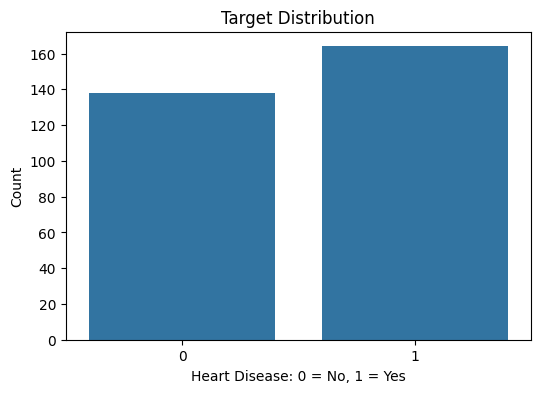

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Target Distribution")
plt.xlabel("Heart Disease: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()

# **Correlation Heatmap**

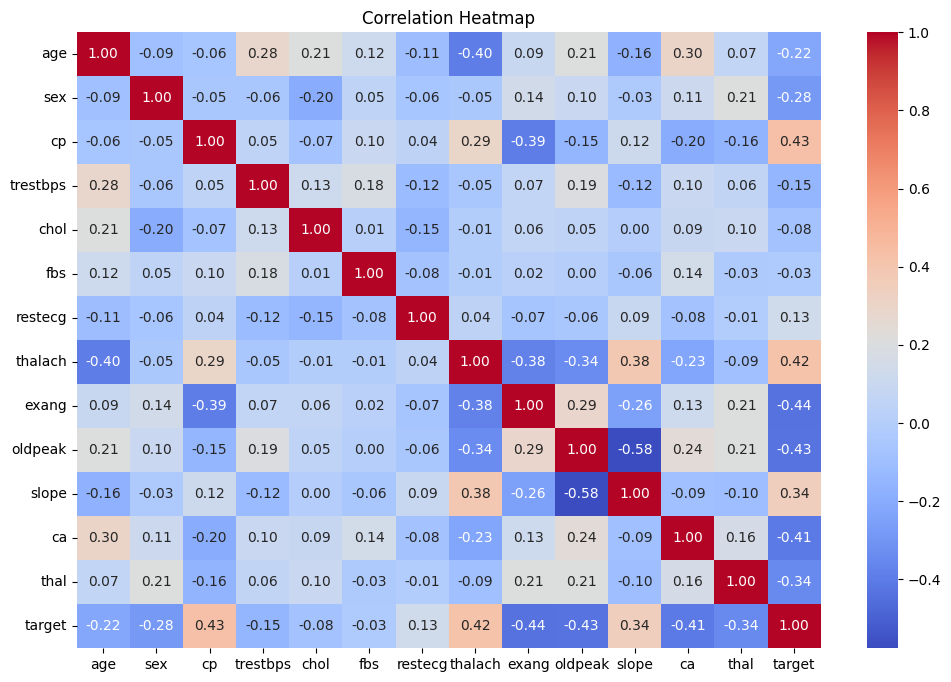

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# **Age Distribution**

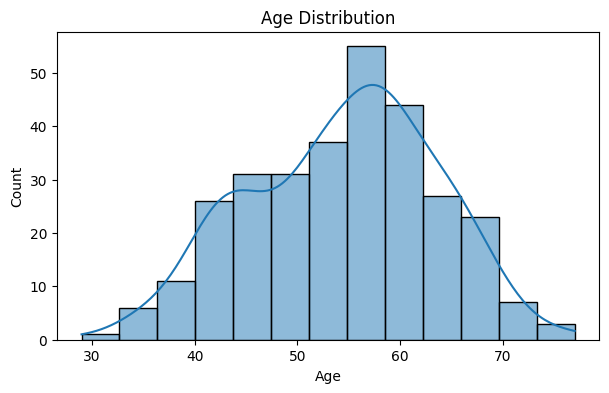

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# **Heart Disease by Gender**

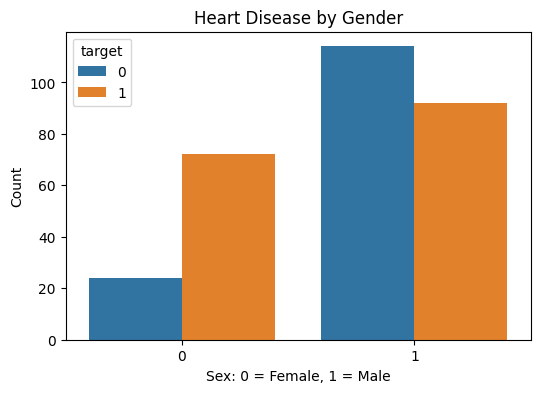

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="sex", hue="target", data=df)
plt.title("Heart Disease by Gender")
plt.xlabel("Sex: 0 = Female, 1 = Male")
plt.ylabel("Count")
plt.show()

# **Chest Pain Type vs Target**

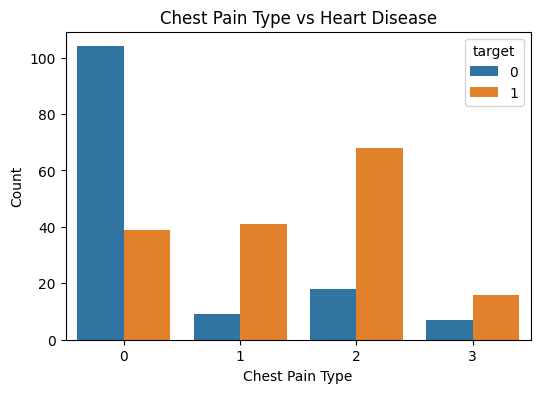

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="cp", hue="target", data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

# **Split Features and Target**

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (302, 13)
Target Shape: (302,)


# **Define Numerical and Categorical Columns**

In [ ]:
numerical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

categorical_cols = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

# **Preprocessing Pipeline**

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# **Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 241
Testing Samples: 61


# **Train Multiple Models**

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_prob = pipeline.decision_function(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.836066,0.848485,0.848485,0.848485,0.904762
1,KNN,0.836066,0.870968,0.818182,0.843750,0.884740
4,Random Forest,0.803279,0.838710,0.787879,0.812500,0.883658
2,SVM,0.786885,0.812500,0.787879,0.800000,0.878788
3,Decision Tree,0.786885,0.812500,0.787879,0.800000,0.801948
5,Gradient Boosting,0.770492,0.787879,0.787879,0.787879,0.827922


# **Cross Validation**

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
    )

    cv_results.append({
        "Model": name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean()
    })

cv_df = pd.DataFrame(cv_results)
cv_df.sort_values(by="F1 Mean", ascending=False)

,Model,Accuracy Mean,F1 Mean,ROC-AUC Mean
0,Logistic Regression,0.854262,0.866884,0.919191
1,KNN,0.831366,0.849381,0.897676
2,SVM,0.831202,0.846631,0.907236
4,Random Forest,0.831257,0.842163,0.908394
5,Gradient Boosting,0.804918,0.822570,0.879992
3,Decision Tree,0.745355,0.762263,0.786188


# **Train Final Best Model**

In [ ]:
best_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8360655737704918
Precision: 0.8484848484848485
Recall: 0.8484848484848485
F1-score: 0.8484848484848485
ROC-AUC: 0.9047619047619048

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        28
           1       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



# **Why We Chose the Final Model?**
After training and evaluating multiple machine learning models, we selected the final model based on its performance using evaluation metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC.

We did not rely on Accuracy only because this is a medical classification problem. In heart disease prediction, it is very important to correctly detect patients who actually have heart disease.

For this reason, we focused more on Recall and F1-score. Recall is important because it measures how many actual heart disease patients were correctly detected by the model. A low Recall means the model may miss sick patients, which can be dangerous in medical applications.

We also considered ROC-AUC because it measures how well the model can distinguish between the two classes: Heart Disease and No Heart Disease.

If Logistic Regression is selected as the final model, it is a good choice because it is simple, stable, easy to interpret, and suitable for binary classification problems. In this project, the output has only two classes: the patient either has heart disease or does not have heart disease.

Logistic Regression works by estimating the probability that a patient belongs to a certain class. In our case, it estimates the probability that a patient has heart disease based on medical features such as age, cholesterol, blood pressure, chest pain type, and maximum heart rate.

If the predicted probability is higher than a certain threshold, the model predicts Heart Disease. If the probability is lower than the threshold, the model predicts No Heart Disease.

Therefore, we chose the final model because it provided strong performance, was easy to explain, and was suitable for our medical binary classification task.

# **Confusion Matrix**

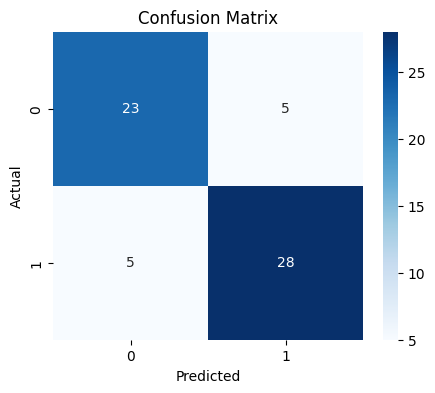

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Save Model**

In [ ]:
joblib.dump(best_model, "heart_disease_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# **Load Model and Predict New Patient**

In [ ]:
loaded_model = joblib.load("heart_disease_model.pkl")

new_patient = pd.DataFrame([{
    "age": 55,
    "sex": 1,
    "cp": 0,
    "trestbps": 140,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 1,
    "oldpeak": 1.5,
    "slope": 1,
    "ca": 0,
    "thal": 2
}])

prediction = loaded_model.predict(new_patient)[0]
probability = loaded_model.predict_proba(new_patient)[0][1]

if prediction == 1:
    print("Prediction: Heart Disease")
else:
    print("Prediction: No Heart Disease")

print("Probability of Heart Disease:", round(probability * 100, 2), "%")

Prediction: No Heart Disease
Probability of Heart Disease: 22.72 %
